# Q3.

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability p, and we want to study the distribution of the survivors.

1. Flip n = 40 coins, which each come up heads with probability p = 1/2 and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, n * p.
3. Divide by the standard deviation sqrt( n * p * (1-p) ).
4. Repeat the above process b = 5_000 times and plot the ECDF.
5. What distribution does this approach as n increases?
6. How do the results change as you adjust p?

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [8]:
rng = np.random.default_rng(20260717)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [9]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(samples, cdf, grid=None, title="", xlabel="", discrete=False, logx=False):
    x, y = ecdf_xy(samples)
    fig, ax = plt.subplots()
    ax.step(x, y, where="post", lw=2, label="simulation ECDF")

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)
    if discrete:
        ax.step(grid, cdf(grid), where="post", lw=2, label="scipy CDF")
    else:
        ax.plot(grid, cdf(grid), lw=2, label="scipy CDF")

    if logx:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()
    return ax


def show_quantiles(samples, dist, probs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    return pd.DataFrame({
        "p": probs,
        "simulation": np.quantile(samples, probs),
        "scipy": dist.ppf(probs),
    })

# Original Graph (1-4)

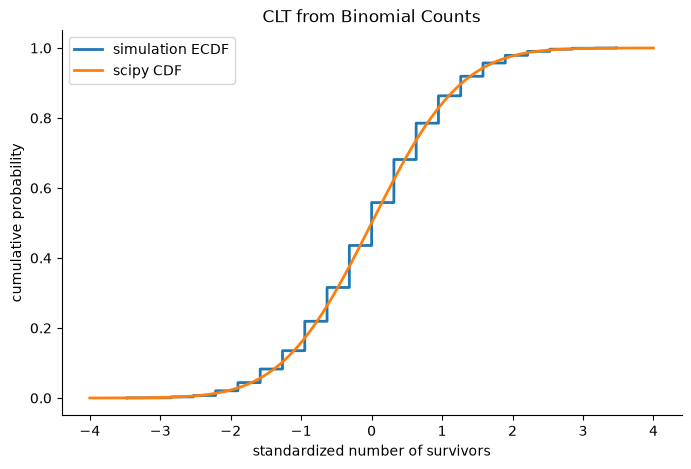

In [10]:
n = 40
p = 1 / 2
b = 5_000

counts = rng.binomial(n, p, size=b)

z_binom = (counts - n * p) / np.sqrt(n * p * (1 - p)) 

normal = stats.norm(0, 1)

plot_ecdf_vs_cdf(z_binom, normal.cdf, grid=np.linspace(-4, 4, 500), title="CLT from Binomial Counts", xlabel="standardized number of survivors")
plt.show()

This is the original graph with n = 40, and we can see that the ECDF aligns fairly well with the CDF. 

# What Happens When We Increase n? (5)

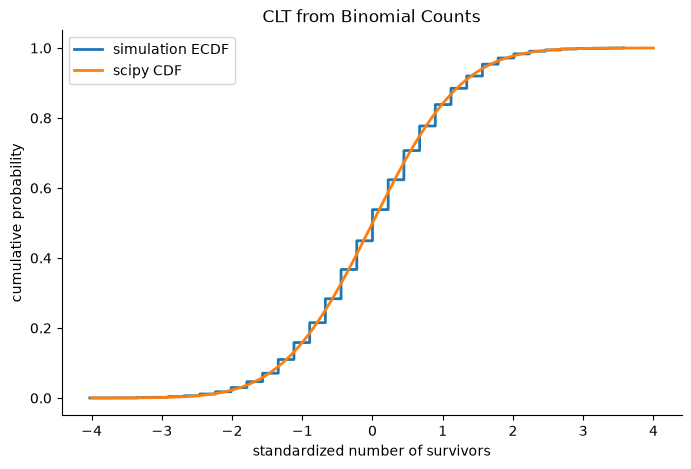

In [11]:
n = 80
p = 1 / 2
b = 5_000

counts = rng.binomial(n, p, size=b)

z_binom = (counts - n * p) / np.sqrt(n * p * (1 - p)) 

normal = stats.norm(0, 1)

plot_ecdf_vs_cdf(z_binom, normal.cdf, grid=np.linspace(-4, 4, 500), title="CLT from Binomial Counts", xlabel="standardized number of survivors")
plt.show()

In this graph, n is doubled from 40 to 80. The steps immediately became smaller and closer to the CDF line. From this, I assume as n grows, the ECDF gets closer to the CDF. As n approaches infinity (which in normal ECDF experiments is not the case), the ECDF line aproaches the CDF line.

# What Happens With Different P-Values? (6)

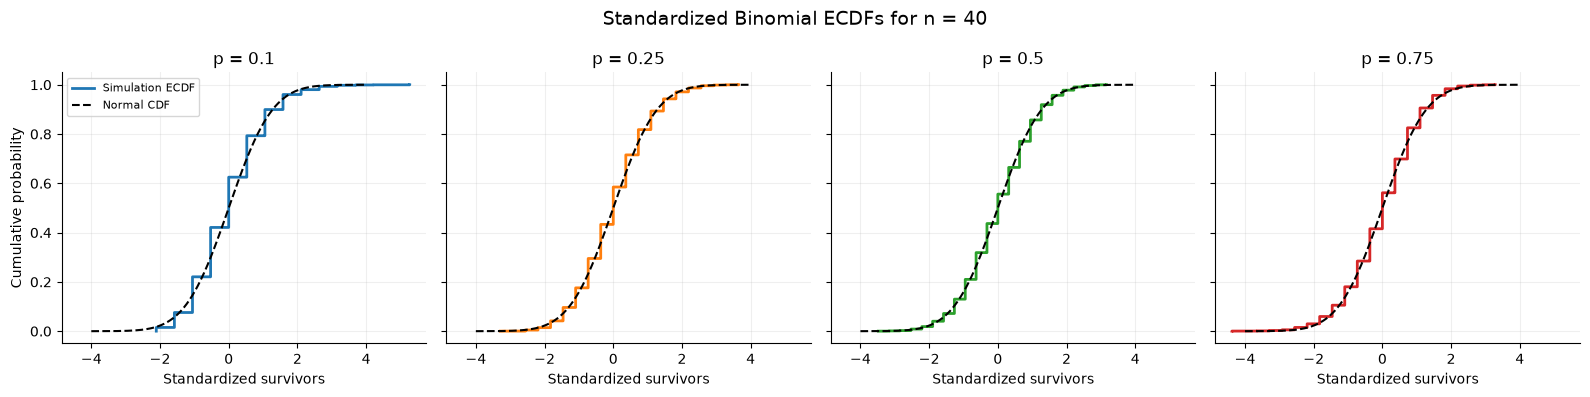

In [12]:
n = 40
b = 5_000

p_values = [0.10, 0.25, 0.50, 0.75]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

normal = stats.norm(0, 1)
grid = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4), sharex=True, sharey=True)

for ax, p, color in zip(axes, p_values, colors):
    
    counts = rng.binomial(n, p, size=b)

    z_binom = (
        counts - n * p
    ) / np.sqrt(n * p * (1 - p))

    x, y = ecdf_xy(z_binom)

    ax.step(x, y, where="post", color=color, linewidth=2, label="Simulation ECDF")

    ax.plot(grid, normal.cdf(grid), color="black", linestyle="--", linewidth=1.5, label="Normal CDF")

    ax.set_title(f"p = {p}")
    ax.set_xlabel("Standardized survivors")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Cumulative probability")
axes[0].legend(fontsize=8)

fig.suptitle(f"Standardized Binomial ECDFs for n = {n}", fontsize=14)

plt.tight_layout()
plt.show()

The higher the p-value, the more accurate the Simulation ECDF is compared to the Normal CDF line. With that said, the results change at a fairly low level. When we look at the graph p = 0.1, it is clearly slightly less accurate than the other graphs, but p = 0.5 and p = 0.75, there is nearly no change.

Used AI to adjust my code I had already made so that there were four graphs next to eachother that are comparable, rather than four large graphs that were all the same color. 